# LAB4. Classification: Telecom Churn

For the following tasks, you will work with [Orange Telecom Customer Churn Dataset](https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets).

**Context**

"*Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.*"

**Content**

The Orange Telecom's Churn Dataset, which consists of cleaned customer activity data, along with a churn label specifying whether a customer canceled the subscription. Two datasets are made available here: train (80% of available data) and test (20% of available data).

**Import libraries**

*   [Pandas](https://pandas.pydata.org/docs/getting_started/index.html#intro-to-pandas) provides data structures to work with relational (tabular) data.
*   [NumPy](https://numpy.org/) provides numerical computing tools (mathematical functions, linear algebra routines, etc.)
*   [Matplotlib](https://matplotlib.org/) allows to create visualizations.
*   [Seaborn](https://seaborn.pydata.org/) is based on Matplotlib. It provides a high-level interface for drawing graphics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# some settings for graphics
sns.set_style("dark")
sns.set(rc={'figure.figsize':(12,4)})

In [ ]:
# use this value where it is possible to indicate the random state
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
df_train = pd.read_csv("https://github.com/eishkina-estia/ML/raw/main/data/telecom-churn/train.csv")
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
df_test = pd.read_csv("https://github.com/eishkina-estia/ML/raw/main/data/telecom-churn/test.csv")
df_test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [ ]:
df_train.shape, df_test.shape

((2666, 20), (667, 20))

## Data preparation

### Preprocessing

* Separate features matrices (`X_train`, `X_test`) and target vectors (`y_train`, `y_test`).
* Preprocess features:
  * Encode `International plan` and `Voice mail plan` features: replace "Yes" by 1, and "No" by 0.
  * Drop `State` feature.
  * Encode `Area code` with one-hot-encoder method, excluding the first resulting vector. Use [`pd.get_dummies`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) method.
* Encode target variable: replace True by 1, and False by 0.
* Check the results (display a few rows)


In [ ]:
# Separate features matrices (X_train, X_test) and target vectors (y_train, y_test)
X_train = df_train.drop(columns='Churn')
y_train = df_train['Churn']
X_test = df_test.drop(columns='Churn')
y_test = df_test['Churn']

In [ ]:
def data_preprocessing(X):
  res = X.copy()
  # Encode International plan and Voice mail plan features: replace "Yes" by 1, and "No" by 0.
  res['International plan'] = res['International plan'].map({'Yes': 1, 'No': 0})
  res['Voice mail plan'] = res['Voice mail plan'].map({'Yes': 1, 'No': 0})
  # Drop State feature.
  res = res.drop(columns=['State'])
  # Encode Area code with one-hot-encoder method, excluding the first resulting vector.
  res = pd.get_dummies(res, columns=['Area code'], drop_first=True)
  return res

X_train = data_preprocessing(X_train)
X_test = data_preprocessing(X_test)

In [ ]:
# Encode target variable: replace True by 1, and False by 0.
def target_preprocessing(y):
  return y.astype(int)

def target_postprocessing(y):
  return y.astype(bool)

y_train = target_preprocessing(y_train)
y_test = target_preprocessing(y_test)

### Balancing classes

Check if the classes are balanced.

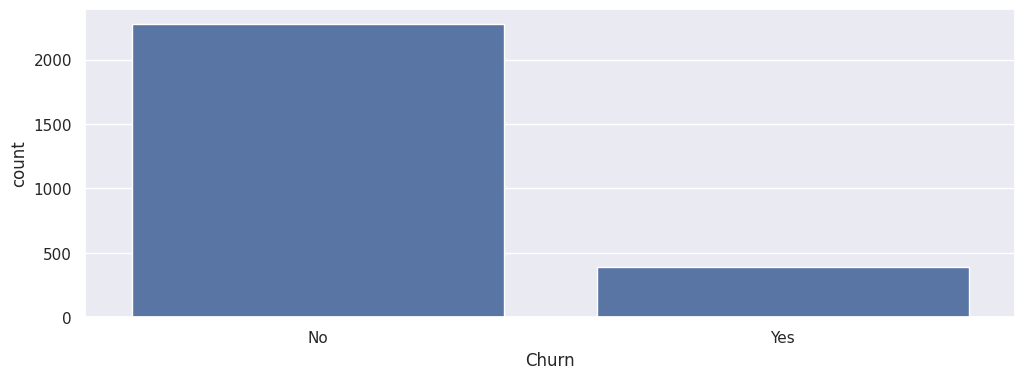

In [ ]:
sns.countplot(x=y_train).set(xticks=[0,1], xticklabels=['No','Yes']);

The challenge of working with imbalanced datasets is that most machine learning techniques will ignore, and in turn have poor performance on, the minority class, although typically it is performance on the minority class that is most important.

[SMOTE](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/): Synthetic Minority Oversampling Technique. It is a data augmentation technique for the minority class.

In [ ]:
!pip install imbalanced-learn

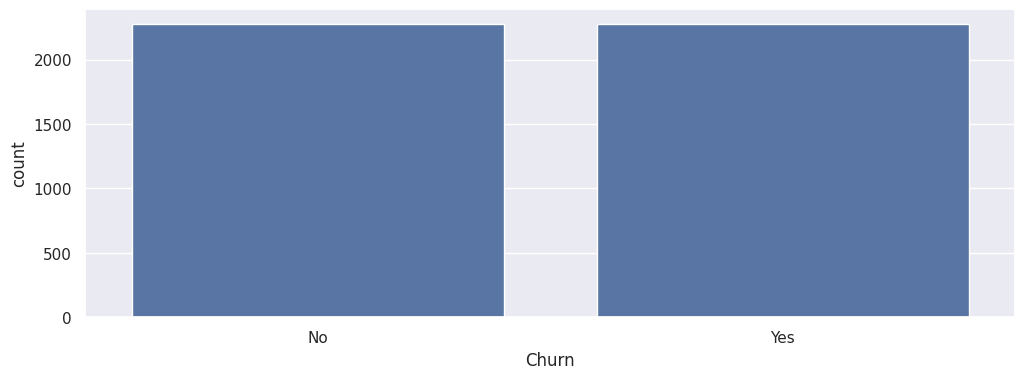

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_train, y_train)

sns.countplot(x=y_res).set(xticks=[0,1], xticklabels=['No','Yes']);

## Baseline

### Logistic Regression

Build [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html) model and display ROC-AUC score calculated on train and test.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

clf_logreg = LogisticRegression(max_iter=10000)
clf_logreg.fit(X_train, y_train)

y_probas_train = clf_logreg.predict_proba(X_train)[:,1]
y_probas_test = clf_logreg.predict_proba(X_test)[:,1]

roc_auc_train = roc_auc_score(y_train, y_probas_train)
roc_auc_test = roc_auc_score(y_test, y_probas_test)

print(f"Train ROC-AUC = {roc_auc_train:.3f}")
print(f"Test  ROC-AUC = {roc_auc_test:.3f}")

Train ROC-AUC = 0.820
Test  ROC-AUC = 0.825


### Decision Tree Classifier

Build [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html) model and display ROC-AUC score calculated on train and test. **Don't forget to pass a value for random_state parameter.**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

clf_dt.fit(X_train, y_train)

y_probas_train = clf_dt.predict_proba(X_train)[:,1]
y_probas_test = clf_dt.predict_proba(X_test)[:,1]

roc_auc_train = roc_auc_score(y_train, y_probas_train)
roc_auc_test = roc_auc_score(y_test, y_probas_test)

print(f"Train ROC-AUC = {roc_auc_train:.3f}")
print(f"Test  ROC-AUC = {roc_auc_test:.3f}")

Train ROC-AUC = 1.000
Test  ROC-AUC = 0.847


### Using [`sklearn.pipeline.Pipeline`](https://scikit-learn.org/1.5/modules/generated/sklearn.pipeline.Pipeline.html)

#### Data preprocessing

In [ ]:
# get the original data
X_train = df_train.drop(columns='Churn')
y_train = df_train['Churn']
X_test = df_test.drop(columns='Churn')
y_test = df_test['Churn']

In [ ]:
# remove one-hot encoding, it will be part of the pipeline
def data_preprocessing(X):
  res = X.copy()
  # Encode International plan and Voice mail plan features: replace "Yes" by 1, and "No" by 0.
  res['International plan'] = res['International plan'].map({'Yes': 1, 'No': 0})
  res['Voice mail plan'] = res['Voice mail plan'].map({'Yes': 1, 'No': 0})
  # Drop State feature.
  res = res.drop(columns=['State'])
  return res

X_train = data_preprocessing(X_train)
X_test = data_preprocessing(X_test)

#### Logistic Regression


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_features = ['Area code']
num_features = [f for f in X_train.columns if f not in cat_features]

# Define data transformation steps
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), cat_features),
    ('scaling', StandardScaler(), num_features)]
)

# Define the whole pipeline: data transformation + model fitting
logreg = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('classifier', LogisticRegression(max_iter=10000))
])

logreg.fit(X_train, y_train)

y_probas_train = logreg.predict_proba(X_train)[:,1]
y_probas_test = logreg.predict_proba(X_test)[:,1]

roc_auc_train = roc_auc_score(y_train, y_probas_train)
roc_auc_test = roc_auc_score(y_test, y_probas_test)

print(f"Train ROC-AUC = {roc_auc_train:.3f}")
print(f"Test  ROC-AUC = {roc_auc_test:.3f}")

Train ROC-AUC = 0.820
Test  ROC-AUC = 0.826


#### Decision Tree Classifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier

cat_features = ['Area code']
num_features = [f for f in X_train.columns if f not in cat_features]

# Define data transformation steps
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), cat_features),
    ('scaling', StandardScaler(), num_features)]
)

# Define the whole pipeline: data transformation + model fitting
dt = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt.fit(X_train, y_train)

y_probas_train = dt.predict_proba(X_train)[:,1]
y_probas_test = dt.predict_proba(X_test)[:,1]

roc_auc_train = roc_auc_score(y_train, y_probas_train)
roc_auc_test = roc_auc_score(y_test, y_probas_test)

print(f"Train ROC-AUC = {roc_auc_train:.3f}")
print(f"Test  ROC-AUC = {roc_auc_test:.3f}")

Train ROC-AUC = 1.000
Test  ROC-AUC = 0.836


## Model improvement

**Hyperparameters tuning**

* Use `train` data to get the best values of hyperparameters by cross-validation: `GridSearchCV` with 3 folds and ROC-AUC scoring
* Assess the quality of the best model got in the previous step, on `test` data

#### Logistic Regression

Tune hyperparameters for Logistic Regression:

* `C` - inverse of regularization strength (see documentation).

Check the model performance on train and test data.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'classifier__C' : np.linspace(0.1, 10.01, 20)}
gs = GridSearchCV(logreg, params, cv=3, scoring='roc_auc', verbose=2)
gs.fit(X_train, y_train)
gs.best_score_, gs.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ..................................classifier__C=0.1; total time=   0.2s
[CV] END ..................................classifier__C=0.1; total time=   0.1s
[CV] END ..................................classifier__C=0.1; total time=   0.2s
[CV] END ....................classifier__C=0.621578947368421; total time=   0.2s
[CV] END ....................classifier__C=0.621578947368421; total time=   0.2s
[CV] END ....................classifier__C=0.621578947368421; total time=   0.2s
[CV] END ...................classifier__C=1.1431578947368422; total time=   0.2s
[CV] END ...................classifier__C=1.1431578947368422; total time=   0.1s
[CV] END ...................classifier__C=1.1431578947368422; total time=   0.2s
[CV] END ...................classifier__C=1.6647368421052633; total time=   0.2s
[CV] END ...................classifier__C=1.6647368421052633; total time=   0.2s
[CV] END ...................classifier__C=1.6647

(0.810196412297152, {'classifier__C': 0.1})

In [ ]:
logreg_best = gs.best_estimator_

y_pred_logreg = logreg_best.predict_proba(X_test)[:,1]
roc_auc_logreg = roc_auc_score(y_test, y_pred_logreg)
print(roc_auc_logreg)

0.8254876702245123


#### Decision Tree Classifier

Tune hyperparameters for Decision Tree Classifier:

* `max_depth` - maximum depth of the tree,
* `criterion` - function to measure the quality of a split

Check the model performance on train and test data.

In [ ]:
# your code here
from sklearn.model_selection import GridSearchCV

params = {'classifier__max_depth' : np.arange(1, 11, 1), 'classifier__criterion' : ["gini", "entropy"]}
gs = GridSearchCV(dt, params, cv=3, scoring='roc_auc', verbose=2)
gs.fit(X_train, y_train)
gs.best_score_, gs.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__criterion=gini, classifier__max_depth=1; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=1; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=1; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=2; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=2; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=2; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=3; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=3; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=3; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=4; total time=   0.0s
[CV] END classifier__criterion=gini, classifier__max_depth=4; total time=   0.0s
[CV] END classifier__criterion=gini, classifier_

(0.8717485777900338,
 {'classifier__criterion': 'entropy', 'classifier__max_depth': 5})

In [ ]:
dt_best = gs.best_estimator_

y_pred_dt = dt_best.predict_proba(X_test)[:,1]
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print(roc_auc_dt)

0.8806956201693045


Compare the quality of the two best models.

In [ ]:
print(roc_auc_logreg)
print(roc_auc_dt)

0.8254876702245123
0.8806956201693045


Display ROC-curve for the best model.

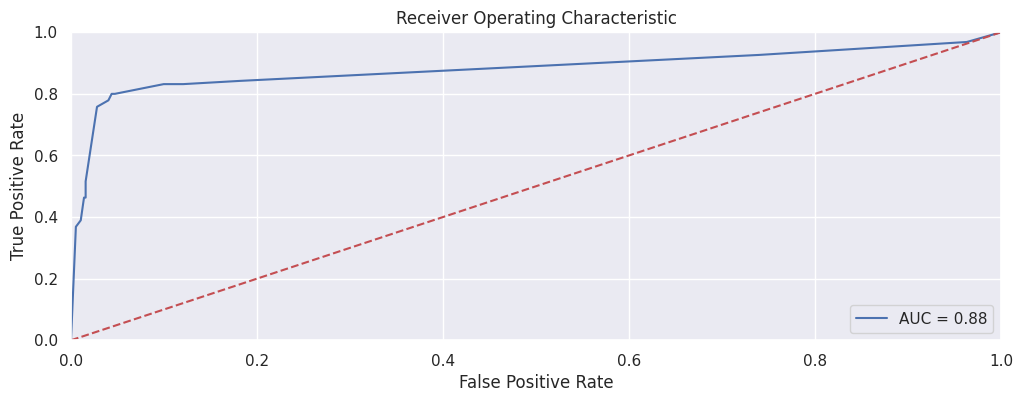

In [ ]:
from sklearn.metrics import roc_curve, auc
from matplotlib import pyplot as plt

fpr, tpr, threshold = roc_curve(y_test, y_pred_dt)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();